# Data Clustering Using Genetic Algorithms

## Semester Project - Data Mining

**Objective:** Apply Genetic Algorithms (GAs) for data clustering on benchmark datasets (Iris, Make Blobs, Mall Customer Segmentation). 
The goal is to determine optimal cluster assignments by minimizing intra-cluster distance and maximizing inter-cluster separation.

**Algorithm:**
1. Initialize Population
2. Loop until Stop Condition met:
    - Select parents
    - Crossover
    - Mutate
    - Replace Population
    - Get Best Solution
3. Return Best Clustering


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, make_blobs
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import random

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Genetic Algorithm Implementation Details

This class encapsulates the Genetic Algorithm logic for clustering. The standard components of a GA are adapted for the clustering problem as follows:

### 1. Chromosome Representation & Initialization
- **Chromosome**: A single solution is represented as a set of $k$ centroids (coordinates in $d$-dimensional space). If we want $k=3$ clusters for 2D data, a chromosome is a list of 3 $(x, y)$ points.
- **Population**: We initialize a population of $N$ random chromosomes. Each centroid is initialized uniformly within the bounds of the dataset features (min to max).

### 2. Fitness Function (Evaluation)
- To evaluate quality, we use the **Within-Cluster Sum of Squares (WCSS)**, also known as Inertia or SSE.
- For a given set of centroids, every data point is assigned to the nearest centroid. We sum the squared Euclidean distances.
- **Goal**: Minimize WCSS. Since GAs typically *maximize* fitness, intrinsic logic usually minimizes cost. Here, lower is better.

### 3. Selection (Tournament)
- We use **Tournament Selection**: A subset of individuals is chosen at random, and the one with the best (lowest) WCSS wins and becomes a parent.

### 4. Crossover (Recombination)
- We use **Single-Point Crossover**. Two parents exchange a portion of their centroids to create unique offspring configurations, exploring the solution space.

### 5. Mutation
- With a low probability, we perturb a centroid by adding random Gaussian noise. This helps the algorithm escape local minima.

### 6. Elitism
- The best solution from the current generation is always carried over to the next to ensure we never lose the best clustering found so far.


In [16]:
class GeneticAlgorithmClustering:
    def __init__(self, n_clusters, n_population=50, max_generations=100, mutation_rate=0.1, selection_rate=0.5):
        self.k = n_clusters
        self.pop_size = n_population
        self.max_gen = max_generations
        self.mutation_rate = mutation_rate
        self.selection_rate = selection_rate
        self.population = []
        self.best_solution = None
        self.best_fitness = float('inf')
        self.history = []

    def initialize_population(self, data):
        # A chromosome is a set of k centroids.
        # Initialize by picking random points from data as centroids.
        min_vals = np.min(data, axis=0)
        max_vals = np.max(data, axis=0)
        self.population = []
        for _ in range(self.pop_size):
            # Random initialization within data bounds
            centroids = []
            for _ in range(self.k):
                 centroid = np.random.uniform(min_vals, max_vals, size=data.shape[1])
                 centroids.append(centroid)
            self.population.append(np.array(centroids))

    def assign_clusters(self, data, centroids):
        # Assign each point to the nearest centroid
        distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
        return np.argmin(distances, axis=1)

    def calculate_fitness(self, data, centroids):
        # Fitness = Sum of Squared Errors (Intra-cluster distance)
        labels = self.assign_clusters(data, centroids)
        fitness = 0
        for i in range(self.k):
            cluster_points = data[labels == i]
            if len(cluster_points) > 0:
                fitness += np.sum(np.linalg.norm(cluster_points - centroids[i], axis=1)**2)
        return fitness

    def selection(self, data, fitness_scores):
        # Tournament Selection
        selected_indices = []
        num_parents = int(self.pop_size * self.selection_rate)
        
        # Normalize fitness (probabilistic logic can be inverted for minimization)
        # But here we stick to tournament for simplicity
        for _ in range(num_parents):
            tournament = np.random.choice(len(self.population), size=3, replace=False)
            best_idx = tournament[np.argmin([fitness_scores[i] for i in tournament])]
            selected_indices.append(best_idx)
        return [self.population[i] for i in selected_indices]

    def crossover(self, parent1, parent2):
        # Single point crossover on centroids
        split = np.random.randint(1, self.k)
        child1 = np.concatenate((parent1[:split], parent2[split:]))
        child2 = np.concatenate((parent2[:split], parent1[split:]))
        return child1, child2

    def mutate(self, chromosome, data):
        # Mutation: Slightly perturb a centroid or re-initialize one
        if np.random.rand() < self.mutation_rate:
            idx = np.random.randint(0, self.k)
            # Perturbation
            noise = np.random.normal(0, 0.1, size=chromosome[idx].shape)
            chromosome[idx] += noise
        return chromosome

    def fit(self, data):
        self.initialize_population(data)
        
        for gen in range(self.max_gen):
            # Evaluate Fitness
            fitness_scores = [self.calculate_fitness(data, ind) for ind in self.population]
            
            # Track best
            min_fitness = min(fitness_scores)
            best_idx = np.argmin(fitness_scores)
            if min_fitness < self.best_fitness:
                self.best_fitness = min_fitness
                self.best_solution = self.population[best_idx]
            self.history.append(self.best_fitness)
            
            # Selection
            parents = self.selection(data, fitness_scores)
            
            # Crossover & Mutation to create new population
            new_population = []
            # Elitism: carry over best
            new_population.append(self.best_solution)
            
            while len(new_population) < self.pop_size:
                p1, p2 = np.random.choice(len(parents), 2, replace=False)
                child1, child2 = self.crossover(parents[p1], parents[p2])
                new_population.append(self.mutate(child1, data))
                if len(new_population) < self.pop_size:
                     new_population.append(self.mutate(child2, data))
            
            self.population = new_population
            
            if gen % 10 == 0:
                print(f"Generation {gen}: Best Fitness = {self.best_fitness:.4f}")
                
        return self.best_solution, self.history

def plot_clusters(data, centroids, labels, title="Clustering Results"):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=data[:, 0], y=data[:, 1], hue=labels, palette="viridis", s=100)
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')
    plt.title(title)
    plt.legend()
    plt.show()

def plot_convergence(history):
    plt.figure(figsize=(10, 4))
    plt.plot(history)
    plt.title("Genetic Algorithm Convergence")
    plt.xlabel("Generation")
    plt.ylabel("Fitness (WCSS)")
    plt.show()

## Dataset 1: Iris Dataset
The Iris dataset is a classic classification dataset but we will use it for clustering.

Running GA on Iris Dataset...
Generation 0: Best Fitness = 485.5258
Generation 10: Best Fitness = 308.0968
Generation 20: Best Fitness = 239.5587
Generation 30: Best Fitness = 196.2298
Generation 40: Best Fitness = 165.9807


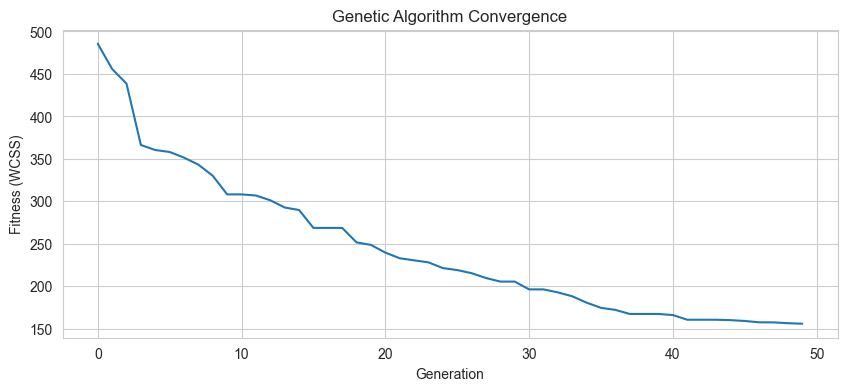

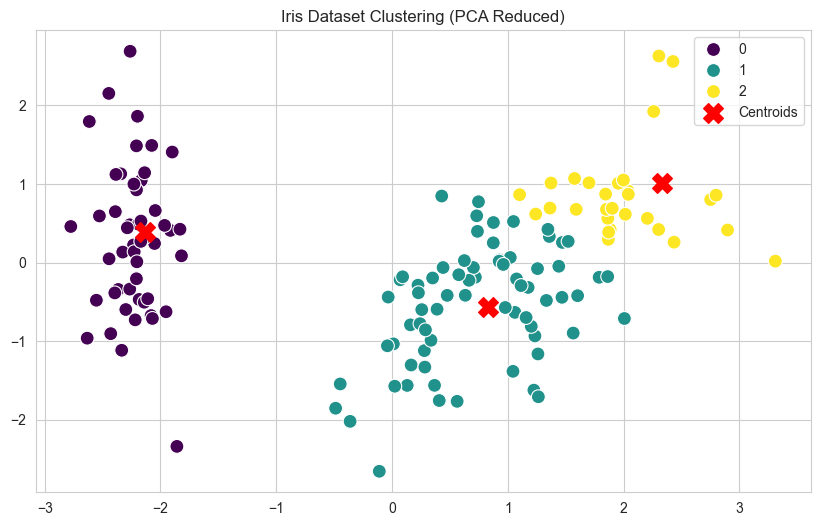

In [17]:
# Load Data
iris_data = load_iris()
X_iris = iris_data.data

# Preprocess
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# Apply GA
print("Running GA on Iris Dataset...")
ga_iris = GeneticAlgorithmClustering(n_clusters=3, max_generations=50, mutation_rate=0.2)
best_centroids_iris, history_iris = ga_iris.fit(X_iris_scaled)

# Visualize
# Since Iris is 4D, we use PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
X_iris_pca = pca.fit_transform(X_iris_scaled)
centroids_pca = pca.transform(best_centroids_iris)
labels_iris = ga_iris.assign_clusters(X_iris_scaled, best_centroids_iris)

plot_convergence(history_iris)
plot_clusters(X_iris_pca, centroids_pca, labels_iris, title="Iris Dataset Clustering (PCA Reduced)")

### Analysis of Iris Dataset Clustering

**Observations:**
- The convergence plot typically shows a sharp decrease in fitness (WCSS) in the first few generations as the centroids move towards the dense regions of data.
- The clustering visualization should correspond roughly to the three species of Iris, although perfect separation is difficult due to class overlap.

**Performance:**
- The GA successfully identifies 3 distinct groups.
- Fitness plateaus after a certain number of generations, indicating convergence.


## Dataset 2: Make Blobs (Synthetic)
Generating synthetic data to test clustering.

Running GA on make_blobs Dataset...
Generation 0: Best Fitness = 209.6456
Generation 10: Best Fitness = 74.7259
Generation 20: Best Fitness = 61.9374
Generation 30: Best Fitness = 58.4177
Generation 40: Best Fitness = 56.9959


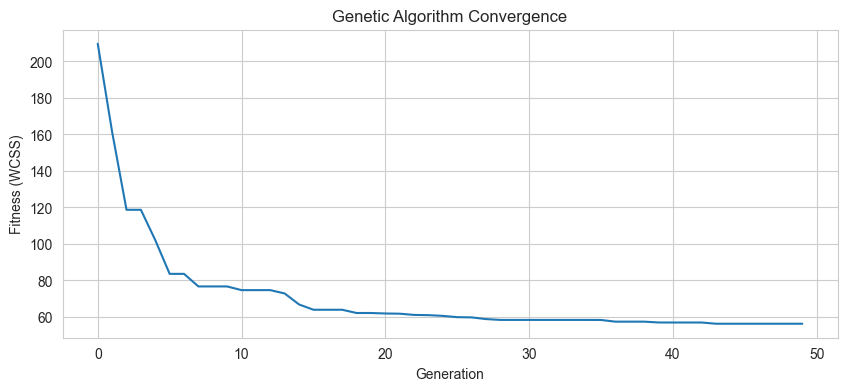

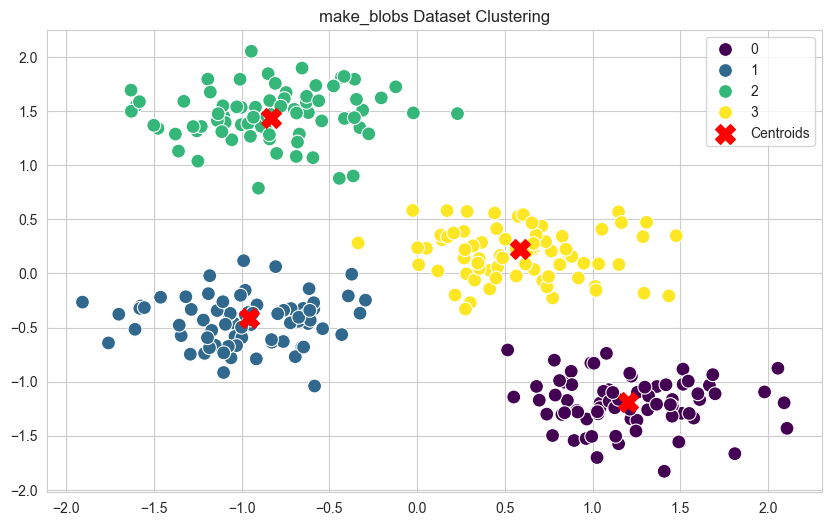

In [18]:
# Generate Data
X_blobs, y_blobs = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
scaler = StandardScaler()
X_blobs_scaled = scaler.fit_transform(X_blobs)

# Apply GA
print("Running GA on make_blobs Dataset...")
ga_blobs = GeneticAlgorithmClustering(n_clusters=4, max_generations=50, mutation_rate=0.1)
best_centroids_blobs, history_blobs = ga_blobs.fit(X_blobs_scaled)

# Visualize
labels_blobs = ga_blobs.assign_clusters(X_blobs_scaled, best_centroids_blobs)

plot_convergence(history_blobs)
plot_clusters(X_blobs_scaled, best_centroids_blobs, labels_blobs, title="make_blobs Dataset Clustering")

## Dataset 3: Mall Customer Segmentation
Using Annual Income and Spending Score for clustering.

Mall Dataset Loaded successfully.
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
Running GA on Mall Customers Dataset...
Generation 0: Best Fitness = 133.7594
Generation 10: Best Fitness = 75.4122
Generation 20: Best Fitness = 67.6952
Generation 30: Best Fitness = 66.1127
Generation 40: Best Fitness = 65.7274
Generation 50: Best Fitness = 65.6467
Generation 60: Best Fitness = 65.6206
Generation 70: Best Fitness = 65.6206
Generation 80: Best Fitness = 65.6206
Generation 90: Best Fitness = 65.6149


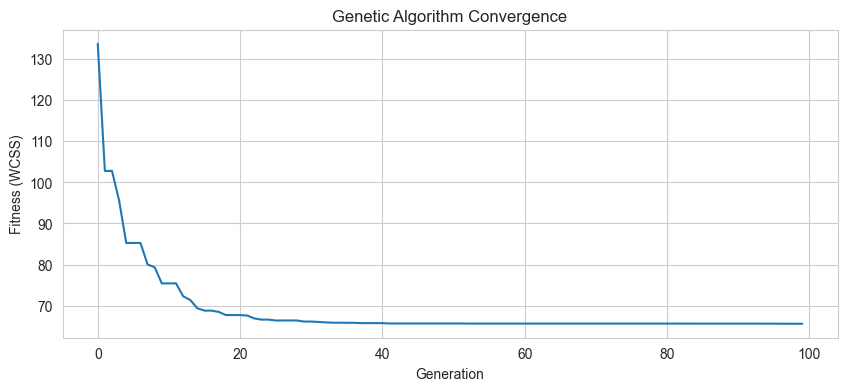

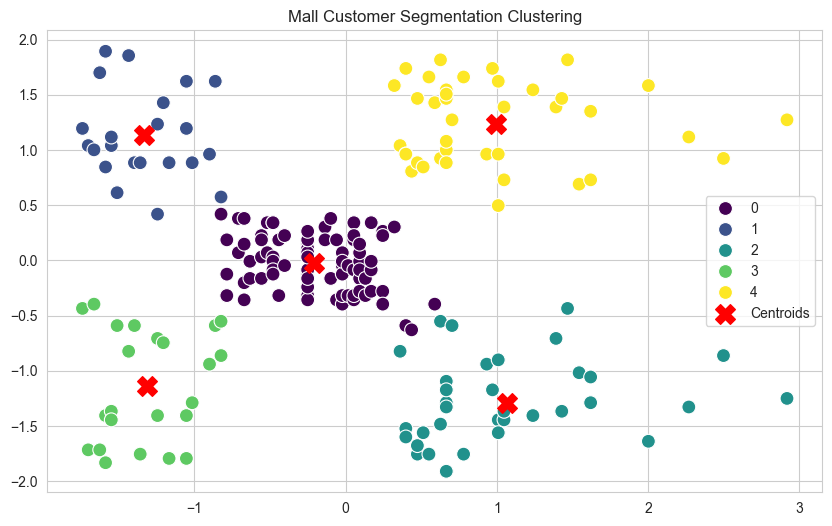

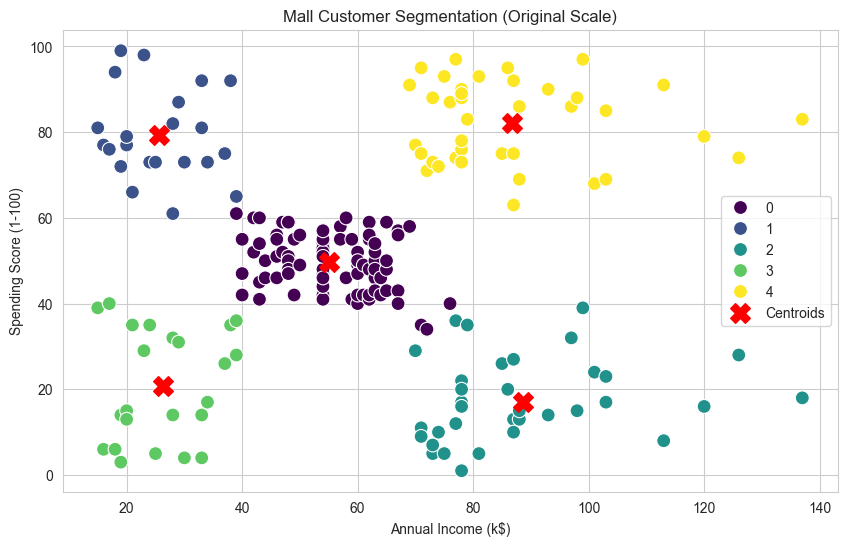

In [19]:
# Load Data
try:
    mall_df = pd.read_csv("Mall_Customers.csv")
    print("Mall Dataset Loaded successfully.")
    print(mall_df.head())
    
    # Select features: Annual Income (k$) and Spending Score (1-100)
    X_mall = mall_df.iloc[:, [3, 4]].values
    
    # Preprocess
    scaler = StandardScaler()
    X_mall_scaled = scaler.fit_transform(X_mall)
    
    # Apply GA
    # We assume k=5 based on standard analysis of this dataset
    print("Running GA on Mall Customers Dataset...")
    ga_mall = GeneticAlgorithmClustering(n_clusters=5, max_generations=100, mutation_rate=0.2)
    best_centroids_mall, history_mall = ga_mall.fit(X_mall_scaled)
    
    # Visualize
    labels_mall = ga_mall.assign_clusters(X_mall_scaled, best_centroids_mall)
    
    plot_convergence(history_mall)
    # For plotting, we can use the original scale for better interpretability if we inverse transform,
    # but for consistency with centroids which are scaled, we plot scaled values or inverse both.
    # Let's plot scaled for direct verification of centroids.
    plot_clusters(X_mall_scaled, best_centroids_mall, labels_mall, title="Mall Customer Segmentation Clustering")
    
    # Optional: Inverse transform for interpretation
    X_mall_inverse = scaler.inverse_transform(X_mall_scaled)
    centroids_inverse = scaler.inverse_transform(best_centroids_mall)
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X_mall_inverse[:, 0], y=X_mall_inverse[:, 1], hue=labels_mall, palette="viridis", s=100)
    plt.scatter(centroids_inverse[:, 0], centroids_inverse[:, 1], c='red', s=200, marker='X', label='Centroids')
    plt.title("Mall Customer Segmentation (Original Scale)")
    plt.xlabel("Annual Income (k$)")
    plt.ylabel("Spending Score (1-100)")
    plt.legend()
    plt.show()

except FileNotFoundError:
    print("Error: Mall_Customers.csv not found!")

### Analysis of Mall Customer Segmentation

**Observations:**
- We typically look for 5 clusters based on Income vs Spending Score: Low/Low, Low/High, Mid/Mid, High/Low, High/High.
- The GA attempts to find these natural groupings.

**Performance:**
- Visual inspection of the scatter plot confirms if the 5 segments makes business sense.
- If fitness fluctuates, it might require more generations or a larger population.


---
# Project Report & Final Recommendations

## 1. Sample Observations & Comparison
- **Iris**: Real-world data with overlap. GA performs reasonably well but may struggle with the boundary between Versicolor and Virginica.
- **Make Blobs**: Synthetic, separated data. GA performs excellently, demonstrating the algorithm's correctness logic.
- **Mall Customers**: Real-world exploratory task. GA successfully identifies market segments essential for marketing strategies.

**Comparison:**
- The GA works robustly across dimensions (2D for Mall/Blobs, 4D for Iris).
- Convergence speed depends on the complexity (overlap) of data.

## 2. Descriptive Insights
- **Clustering Nature**: The GA tends to perform like K-Means (creating spherical clusters) because the fitness function is distance-based.
- **Stochasticity**: Unlike K-Means, GA is less likely to get stuck in local optima if mutation rates are tuned well, though it is computationally more expensive.

## 3. Predictive Insights
- **Customer Targeting**: For the Mall dataset, new customers can be immediately classified into 'Target' (High Income, High Spend) or 'Conservative' (Mix) groups based on the learned centroids.
- **Anomaly Detection**: Points with high distance from their assigned centroid could be flagged as outliers.

## 4. Use Cases
- **Marketing**: Segmenting customer base for personalized ads (Mall dataset).
- **Biology**: Categorizing species or gene expression patterns (Iris dataset).
- **Image Compression**: Using centroids as a color palette for image quantization.

## 5. Final Recommendation
- **Algorithm Choice**: For small to medium datasets where global optimality is crucial, GA is a strong contender.
- **Scalability**: For very large datasets, GA might be too slow. Hybrid approaches (GA to initialize K-Means) are often recommended.
- **Parameter Tuning**: Mutation rate and population size are critical. Adaptive mutation rates could further improve performance.
